**Drew Hill & Esther Suravarapu**

run_corridor_experiment.ipynb

This notebook runs the corridor experiment replicating the experiment from the 
duel network architecture paper we reviewed.

In [16]:
import numpy as np
import torch 
import matplotlib.pyplot as plt
import random

import sys
import os

sys.path.append(os.path.abspath('..'))

from enviornments.corridor import CorridorEnv
from networks.single_stream import SingleStreamNetwork
from networks.dueling import DuelingNetwork
import experiments.evaluation as e

from training import expected_sarsa

from matplotlib.ticker import MaxNLocator

In [2]:
def setup_experiment(num_actions, num_states, gamma, epsilon):
    """
        Sets up the corridor experiment by building the enviornment, the q_pi answer key, and 
        both the single and duel stream networks.

        num_actions: int - The number of possible actions.
        num_states: int - The number of states in the enviornment.
        gamma: float - Discount factor.
        epsilon: float - Probability of taking random action.
        returns env, pi, q_pi, single, duel
    """
    # Creates the enviornment. 
    env = CorridorEnv(num_actions, num_states, gamma)

    # Builds the evaluation answer key using value iteratin.
    q = e.value_iteration(env, 1e-10, 100000)
    pi = e.eps_greedy_policy(env, q, epsilon)
    q_pi = e.policy_evaluation(env, pi, 1e-12, 200000)

    # Builds single and duel networks.
    single = SingleStreamNetwork(env.num_states, 50, env.num_actions)
    duel = DuelingNetwork(env.num_states, env.num_actions, 50, 25)

    return env, pi, q_pi, single, duel

In [3]:
def network_q_table(network, env):
    """
        Gets the networks predicted q table.

        network: torch.nn - The network.
        env: CorridorEnv - The enviornment.
        returns the networks q values for every state.
    """
    # Builds the one hot vector for each state.
    all_states = torch.eye(env.num_states)

    with torch.no_grad():
        # Runs each states one hot vector trough the network to get q values.
        q = network(all_states)

    return q.numpy()

def train(network, env, pi, q_pi, num_iters, epsilon, gamma, record_every, alpha):
    """
        Trains a network using expected SARSA for all states. Then records the 
        squared error against the answer key produced from policy evaluation.

        network: torch.nn - The network being trained.
        env: CorridorEnv - The enviornment.
        pi: array - The epsilon greedy policy probabilities.
        q_pi: array - The actual q values.
        num_iters: int Number of iterations.
        epsilon: float - Probability of a random action.
        gamma: float - Discount factor.
        record_every: int - How often to recored the squared error.
        alpha: float - Learing rate.
        returns a list  with iterations and squared errors.
    """ 
    optimizer = torch.optim.Adam(network.parameters(), lr=alpha)
    pi_tensor = torch.tensor(pi, dtype=torch.float32)
    all_states = torch.eye(env.num_states)
    curve = []

    state = env.reset()

    for i in range(num_iters):

        next_state_indecies = []
        actions = []
        rewards = []
        terminal = []

        for state in range(env.num_states):
            action = random.randint(0, env.num_actions - 1)
            next_state = env.transition(state, action)
            actions.append(action)
            next_state_indecies.append(next_state)
            
            if next_state == env.end_state:
                rewards.append(1.0)
                terminal.append(1.0)
            
            else:
                rewards.append(0.0)
                terminal.append(0.0)

        actions = torch.tensor(actions)
        rewards = torch.tensor(rewards, dtype=torch.float32)
        next_states = all_states[next_state_indecies]
        terminal = torch.tensor(terminal)

        q_values = network(all_states)
        q_selected = q_values.gather(1, actions.unsqueeze(1)).squeeze(1)

        with torch.no_grad():
            next_q_values = network(next_states)
            next_pi = pi_tensor[next_states.argmax(dim=1)]
            expected_next = (next_pi * next_q_values).sum(dim=1)
            target = rewards + gamma * expected_next * (1 - terminal)

        loss = torch.nn.functional.mse_loss(q_selected, target)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(network.parameters(), 1.0)
        optimizer.step()

        if i % record_every == 0:
            se = e.compute_se(q_pi, network_q_table(network, env))
            curve.append((i, se))

    return curve

def averaged_training(network_type, env, pi, q_pi, num_iters, epsilon, gamma, record_every, alpha, seeds):
    """

    """ 
    all_curves = []

    for seed in seeds:
        random.seed(seed)
        np.random.seed(seed)
        torch.manual_seed(seed)

        if network_type == "single":
            network = SingleStreamNetwork(env.num_states, 50, env.num_actions)

        else:
            network = DuelingNetwork(env.num_states, env.num_actions, 50, 25)

        curve = train(network, env, pi, q_pi, num_iters, epsilon, gamma, record_every, alpha)

        iterations = []
        squared_errors = []
        for iteration, se in curve:
            iterations.append(iteration)
            squared_errors.append(se)
        
        all_curves.append(squared_errors)

    iterations = np.array(iterations)
    mse = np.mean(np.array(all_curves), axis=0)

    return iterations, mse


In [4]:
def run_experiment(num_states, gamma, epsilon, num_iters, record_every, alpha, seeds):
    """
    
    """
    actions_list = [5, 10, 20]
    results = []

    for num_actions in actions_list:
        env, pi, q_pi, single, duel = setup_experiment(num_actions, num_states, gamma, epsilon)
        single_iter, single_mse = averaged_training("single", env, pi, q_pi, num_iters, epsilon, gamma, record_every, alpha, seeds)
        duel_iter, duel_mse = averaged_training("duel", env, pi, q_pi, num_iters, epsilon, gamma, record_every, alpha, seeds)

        results.append({
            "actions": num_actions,
            "single": (single_iter, single_mse),
            "duel": (duel_iter, duel_mse)
            })

    return results

In [18]:
def plot_curves(results):
    """
    """
    fig, axes = plt.subplots(1, len(results), figsize=(16, 5))

    for i in range(len(results)):
        ax = axes[i]
        r = results[i]

        single_iters, single_se = r["single"]
        duel_iters, duel_se = r["duel"]

        ax.plot(single_iters, single_se, "--", color="crimson", label="Single", linewidth=2)
        ax.plot(duel_iters, duel_se, "-", color="seagreen", label="Dueling", linewidth=2)

        ax.set_title(f"{r['actions']} Actions")
        ax.set_xlabel("Iterations")
        ax.set_ylabel("Squared Error")
        ax.set_xscale("log")
        ax.yaxis.set_major_locator(MaxNLocator(nbins=6))
        ax.legend()

    plt.tight_layout()
    plt.show()

5 actions -> single: 13.1, dueling: 34.1
10 actions -> single: 32.5, dueling: 66.6
20 actions -> single: 83.8, dueling: 191.0
10000


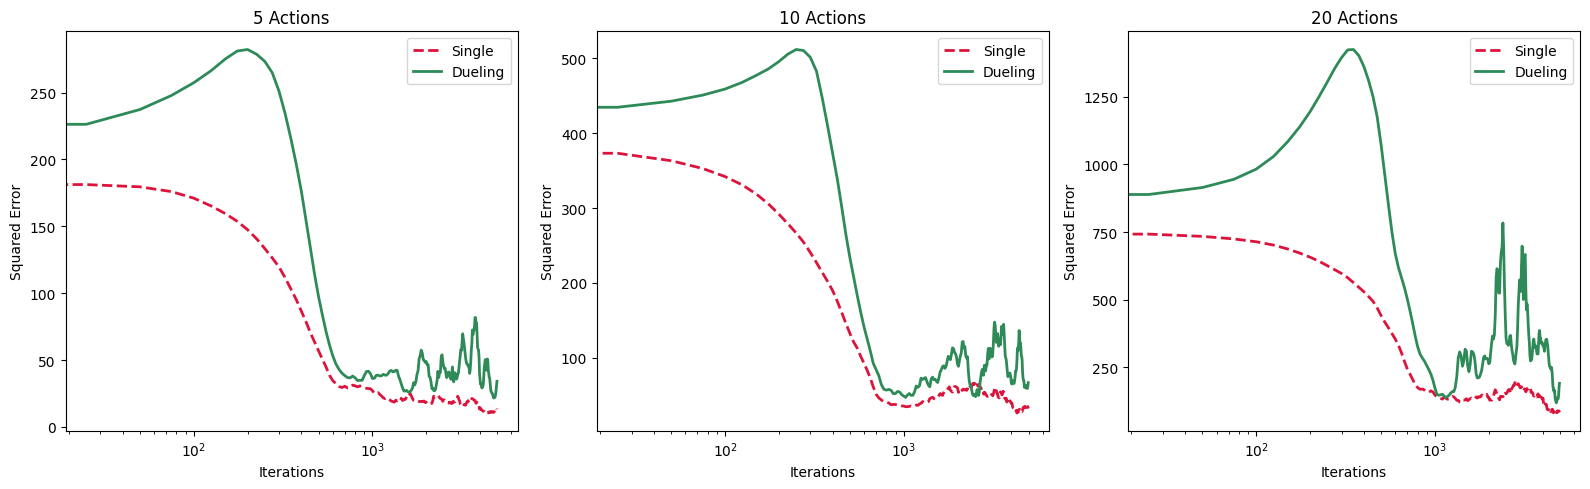

5 actions -> single: 16.9, dueling: 11.5
10 actions -> single: 19.7, dueling: 62.3
20 actions -> single: 49.3, dueling: 88.7
20000


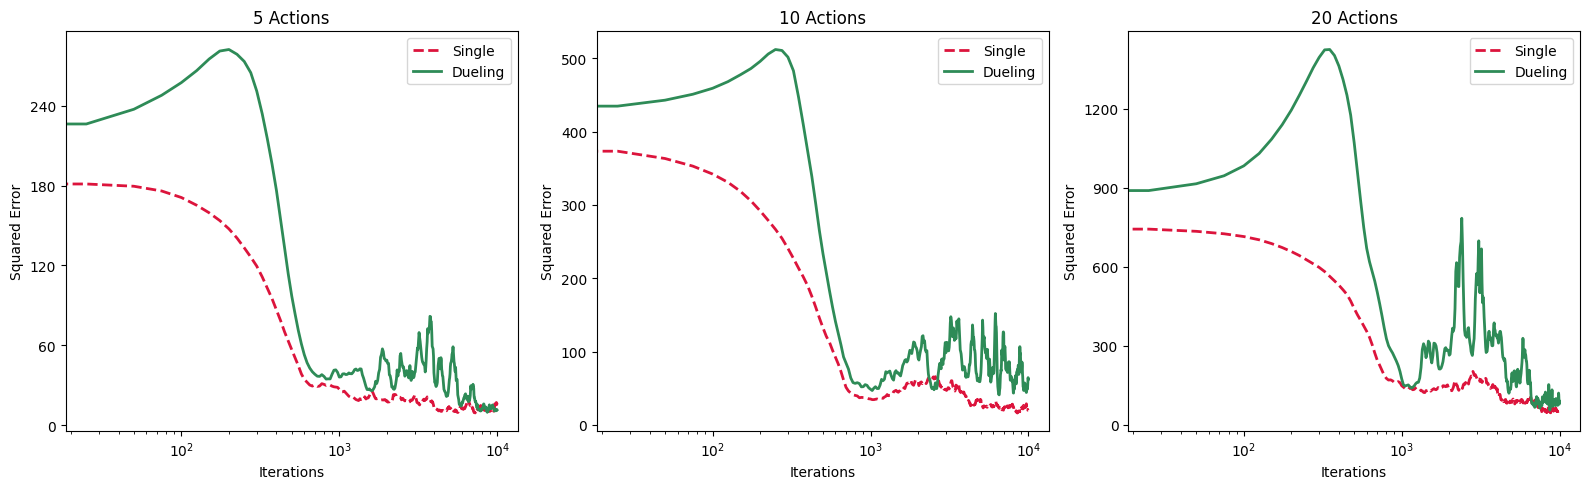

5 actions -> single: 8.4, dueling: 8.8
10 actions -> single: 24.2, dueling: 89.4
20 actions -> single: 28.4, dueling: 2184.9
40000


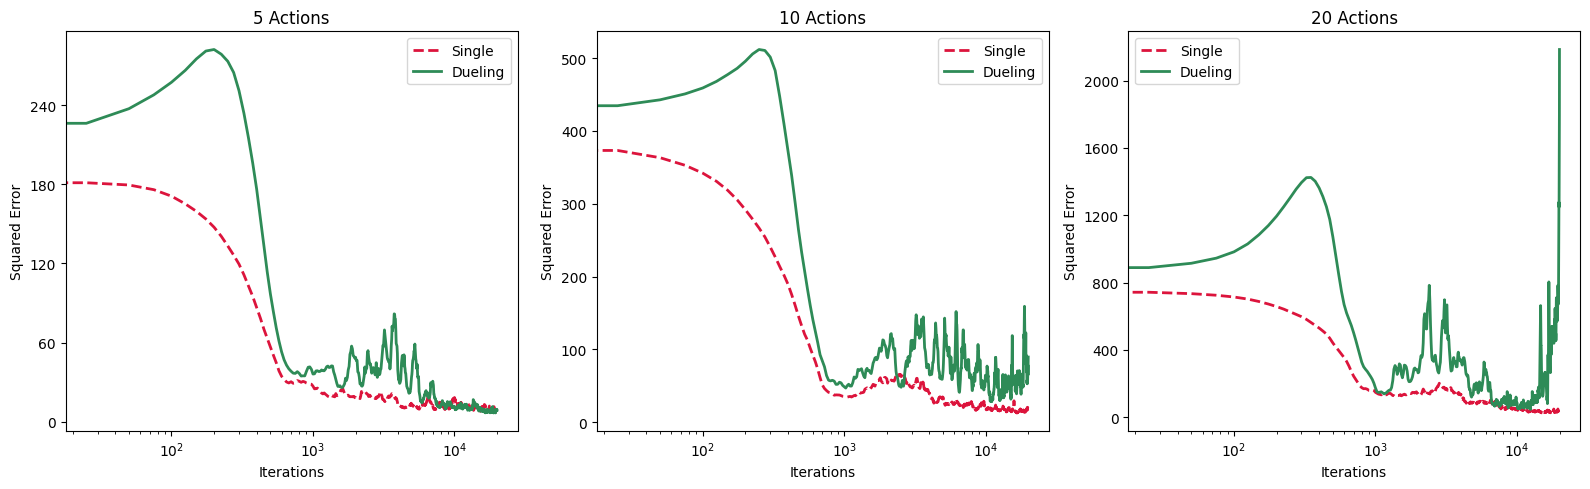

KeyboardInterrupt: 

In [19]:
seeds = (0, 1, 2, 3, 4)
iterations = 5000

for i in range (1, 5):
    results = run_experiment(70, .99, .001, iterations, 25, 2e-4, seeds)
    iterations *= 2

    for r in results:
        single_final = r["single"][1][-1]
        duel_final = r["duel"][1][-1]
        print(f"{r['actions']} actions -> single: {single_final:.1f}, dueling: {duel_final:.1f}")

    print(iterations)
    plot_curves(results)